# Eigen Motif Syntax v2: K562 vs HepG2

**Goal**: Find sequence-agnostic positional eigenmodes (motifs / motif combos)
that describe ISM differences between K562 and HepG2 across all sequences.

**Changes from v1**:
- 2 cell lines only (K562, HepG2)
- Inverted deltas shown as sequence logos (positive = important for activity)
- 1 sequence for visualization, structured for scaling to all seqs
- Region shading for promoter/barcode

**Pipeline**:
1. ISM on each sequence through both models
2. Importance = −mean(ISM delta) per position (neg delta → pos importance)
3. Difference d_i = importance_HepG2 − importance_K562 per sequence → (281,)
4. Stack across N sequences → D of shape (N, 281)
5. Eigendecompose covariance of D → eigenvectors = positional patterns of cell-type divergence

In [21]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import sys
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, REPO_ROOT)
sys.path.insert(0, os.path.join(REPO_ROOT, 'interp'))
sys.path.insert(0, os.path.join(REPO_ROOT, 'interp', 'tangermeme'))

from alphagenome_pytorch import AlphaGenome
from alphagenome_pytorch.extensions.finetuning.transfer import remove_all_heads
from alphagenome_pytorch.extensions.finetuning.utils import sequence_to_onehot
from tangermeme.plot import plot_logo
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.ersatz import dinucleotide_shuffle

# Apply monkey-patches BEFORE loading any model
from ag_deeplift_patches import patch_alphagenome, AGCustomGELU
patch_alphagenome()

print(f'torch {torch.__version__}, CUDA: {torch.cuda.is_available()}')

AlphaGenome patches applied (all functional activations -> nn.Module).
torch 2.10.0+cu128, CUDA: True


In [22]:
ENCODER_DIM = 1536
ENCODER_RESOLUTION_BP = 128


class MPRAHead(nn.Module):
    def __init__(self, n_positions, nl_size=1024, dropout=0.0,
                 activation='relu', pooling_type='flatten', center_bp=256):
        super().__init__()
        self.pooling_type = pooling_type
        self.n_positions = n_positions
        hidden_sizes = [nl_size] if isinstance(nl_size, int) else list(nl_size)
        self.norm = nn.LayerNorm(ENCODER_DIM)
        in_dim = n_positions * ENCODER_DIM if pooling_type == 'flatten' else ENCODER_DIM
        layers = []
        for hs in hidden_sizes:
            layers.append(nn.Linear(in_dim, hs))
            in_dim = hs
        self.hidden_layers = nn.ModuleList(layers)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.output = nn.Linear(in_dim, 1)
        # Module-based activation for DeepLIFT/SHAP hooks
        if activation == 'gelu':
            self.act = nn.GELU()
        else:
            self.act = nn.ReLU()

    def forward(self, encoder_output):
        x = self.norm(encoder_output)
        if self.pooling_type == 'flatten':
            x = x.flatten(1)
        for layer in self.hidden_layers:
            x = self.act(self.dropout(layer(x)))
        return self.output(x).squeeze(-1)


class AlphaGenomeMPRA(nn.Module):
    """End-to-end wrapper: one-hot (B, 4, L) -> scalar prediction.

    For DeepLIFT/SHAP: returns (B, 1).
    For ISM/direct use: returns (B,) when squeeze=True.
    """

    def __init__(self, encoder, head, squeeze=False):
        super().__init__()
        self.encoder = encoder
        self.head = head
        self.squeeze = squeeze

    def forward(self, x):
        x = x.transpose(1, 2)
        org_idx = torch.zeros(x.shape[0], dtype=torch.long, device=x.device)
        enc_out = self.encoder(
            x, org_idx, encoder_only=True
        )['encoder_output'].transpose(1, 2)
        pred = self.head(enc_out)
        if self.squeeze:
            return pred
        return pred.unsqueeze(-1)  # (B, 1) for tangermeme


print('Classes defined.')

Classes defined.


## 1. Setup

Construct = `enhancer (230bp) + promoter (36bp) + barcode (15bp)` = 281bp.  
Promoter and barcode are constant across all sequences.

In [23]:
WEIGHTS_PATH = os.path.join(REPO_ROOT, 'weights', 'model_fold_0.safetensors')
RESULTS_DIR = os.path.join(REPO_ROOT, 'training', 'results')
DATA_DIR = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/test_run_lenti_data'

CELL_TYPE_MODELS = {
    'K562':  'K562_twostep_v4_do075',
    'HepG2': 'HepG2_twostep_v5_do075',
}
cell_types = list(CELL_TYPE_MODELS.keys())

# Construct regions
ENHANCER_LEN = 230
PROMOTER_SEQ = 'TCCATTATATACCCTCTAGTGTCGGTTCACGCAATG'  # 36 bp
RAND_BARCODE = 'AGAGACTGAGGCCAC'                       # 15 bp
PROMOTER_START = ENHANCER_LEN                           # 230
BARCODE_START = ENHANCER_LEN + len(PROMOTER_SEQ)        # 266
TOTAL_LEN = ENHANCER_LEN + len(PROMOTER_SEQ) + len(RAND_BARCODE)  # 281

print(f'Enhancer: 0-{ENHANCER_LEN-1} ({ENHANCER_LEN}bp)')
print(f'Promoter: {PROMOTER_START}-{BARCODE_START-1} ({len(PROMOTER_SEQ)}bp)')
print(f'Barcode:  {BARCODE_START}-{TOTAL_LEN-1} ({len(RAND_BARCODE)}bp)')

# Region masks & colors
enhancer_mask = np.arange(TOTAL_LEN) < PROMOTER_START
promoter_mask = (np.arange(TOTAL_LEN) >= PROMOTER_START) & (np.arange(TOTAL_LEN) < BARCODE_START)
barcode_mask = np.arange(TOTAL_LEN) >= BARCODE_START
REGION_COLORS = {'enhancer': '#2196F3', 'promoter': '#E91E63', 'barcode': '#9C27B0'}

# Load test sequences — use top 1 for now
import pandas as pd
df = pd.read_csv(os.path.join(DATA_DIR, 'HepG2.tsv'), sep='\t')
df = df[df['rev'] == 0]
test_df = df[df['fold'] == 10].reset_index(drop=True)

top_df = test_df.nlargest(1, 'mean_value').reset_index(drop=True)
construct = top_df.iloc[0]['seq'] + PROMOTER_SEQ + RAND_BARCODE
assert len(construct) == TOTAL_LEN

onehot = sequence_to_onehot(construct).astype(np.float32)  # (281, 4)
X0 = torch.from_numpy(onehot).T                            # (4, 281)
print(f'Seq 0: expr={top_df.iloc[0]["mean_value"]:.3f}, shape={X0.shape}')

Enhancer: 0-229 (230bp)
Promoter: 230-265 (36bp)
Barcode:  266-280 (15bp)
Seq 0: expr=4.410, shape=torch.Size([4, 281])


## 2. ISM

In [24]:
BASES = 'ACGT'


def generate_all_single_mutants(onehot):
    """(4, L) -> (N_mut, 4, L) + info list."""
    L = onehot.shape[1]
    mutants, info = [], []
    for p in range(L):
        ref_idx = onehot[:, p].argmax().item()
        for alt_idx in range(4):
            if alt_idx == ref_idx:
                continue
            mut = onehot.clone()
            mut[:, p] = 0
            mut[alt_idx, p] = 1
            mutants.append(mut)
            info.append((p, BASES[ref_idx], BASES[alt_idx]))
    return torch.stack(mutants), info


def run_ism(model, wt_onehot, mutant_onehots, device, batch_size=64):
    """Returns (wt_pred, deltas array of shape (N_mut,))."""
    model.eval()
    with torch.no_grad():
        wt_pred = model(wt_onehot.unsqueeze(0).to(device)).cpu().item()
        deltas = []
        for i in range(0, len(mutant_onehots), batch_size):
            batch = mutant_onehots[i:i+batch_size].to(device)
            preds = model(batch).cpu().numpy()
            deltas.append(preds - wt_pred)
    return wt_pred, np.concatenate(deltas)


def ism_to_importance(deltas, n_positions):
    """ISM deltas -> importance per position.
    importance = -mean(delta): large neg delta = position important = positive importance."""
    return -deltas.reshape(n_positions, 3).mean(axis=1)


def ism_to_logo(deltas, onehot_np, n_positions):
    """ISM deltas -> (4, L) logo matrix for plot_logo."""
    importance = ism_to_importance(deltas, n_positions)
    return onehot_np * importance[np.newaxis, :]


mutants, mut_info = generate_all_single_mutants(X0)
print(f'{len(mutants)} mutants')

843 mutants


In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ism_results = {}  # ct -> (wt_pred, deltas)

for ct, model_name in CELL_TYPE_MODELS.items():
    print(f'\n=== {ct} ({model_name}) ===')
    ckpt_path = os.path.join(RESULTS_DIR, model_name, 'checkpoints', 'best_stage2.pt')
    
    enc = AlphaGenome.from_pretrained(WEIGHTS_PATH, device='cpu')
    remove_all_heads(enc)
    hd = MPRAHead(n_positions=3, nl_size=1024, dropout=0.0,
                  activation='relu', pooling_type='flatten', center_bp=256)
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    enc.load_state_dict(ckpt['model_state_dict'], strict=False)
    hd.load_state_dict(ckpt['head_state_dict'])
    wm = AlphaGenomeMPRA(enc, hd, squeeze=True).to(device).eval()
    
    wt_pred, deltas = run_ism(wm, X0, mutants, device)
    ism_results[ct] = (wt_pred, deltas)
    print(f'  WT pred={wt_pred:.4f}, max|delta|={np.abs(deltas).max():.4f}')
    
    del wm, enc, hd, ckpt
    torch.cuda.empty_cache()

print('\nDone.')


=== K562 (K562_twostep_v4_do075) ===
  WT pred=-0.3311, max|delta|=0.3980

=== HepG2 (HepG2_twostep_v5_do075) ===
  WT pred=3.6263, max|delta|=1.8497

Done.


## 3. ISM importance logos

Positive height = base is important for positive activity (mutating it decreases prediction).  
Both logos on the same y-scale. Promoter and barcode regions shaded.

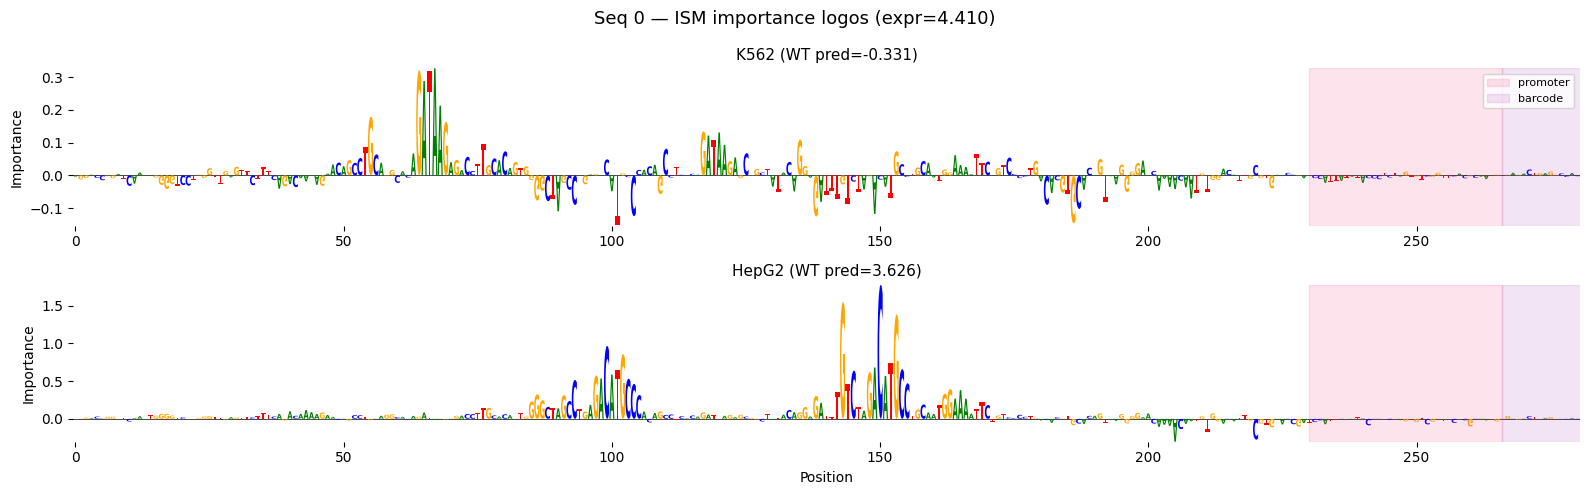

In [26]:
onehot_np = X0.numpy()  # (4, 281)

logos = {ct: ism_to_logo(ism_results[ct][1], onehot_np, TOTAL_LEN) for ct in cell_types}

# Shared y-limits
all_vals = np.concatenate([logos[ct].ravel() for ct in cell_types])
pad = (all_vals.max() - all_vals.min()) * 0.05
shared_ylim = (all_vals.min() - pad, all_vals.max() + pad)

fig, axes = plt.subplots(2, 1, figsize=(16, 5))
fig.suptitle(f'Seq 0 — ISM importance logos (expr={top_df.iloc[0]["mean_value"]:.3f})',
             fontsize=13)

for ci, ct in enumerate(cell_types):
    ax = axes[ci]
    plot_logo(logos[ct], ax=ax, ylim=shared_ylim)
    wt_pred = ism_results[ct][0]
    ax.set_title(f'{ct} (WT pred={wt_pred:.3f})', fontsize=11)
    ax.axvspan(PROMOTER_START, BARCODE_START, alpha=0.12, color=REGION_COLORS['promoter'],
               label='promoter')
    ax.axvspan(BARCODE_START, TOTAL_LEN, alpha=0.12, color=REGION_COLORS['barcode'],
               label='barcode')
    ax.set_ylabel('Importance')
    if ci == 0:
        ax.legend(fontsize=8, loc='upper right')
    if ci == 1:
        ax.set_xlabel('Position')

plt.tight_layout()
plt.show()

## 4. Single-sequence eigendecomposition (K562 vs HepG2)

Importance matrix E of shape (281, 2). PCA gives exactly 2 PCs:
- **PC1**: shared direction (both cell types load same sign)
- **PC2**: differential direction (cell-type-specific positions)

In [27]:
E = np.column_stack([
    ism_to_importance(ism_results[ct][1], TOTAL_LEN) for ct in cell_types
])
print(f'E shape: {E.shape}')

E_centered = E - E.mean(axis=0)
pca = PCA(n_components=2)
scores = pca.fit_transform(E_centered)  # (281, 2)

print(f'\nExplained variance: {pca.explained_variance_ratio_}')
for pc_i in range(2):
    loadings = pca.components_[pc_i]
    desc = ', '.join(f'{ct}:{w:+.3f}' for ct, w in zip(cell_types, loadings))
    print(f'PC{pc_i+1} ({pca.explained_variance_ratio_[pc_i]*100:.1f}%): [{desc}]')

E shape: (281, 2)

Explained variance: [0.9387367  0.06126331]
PC1 (93.9%): [K562:-0.025, HepG2:+1.000]
PC2 (6.1%): [K562:+1.000, HepG2:+0.025]


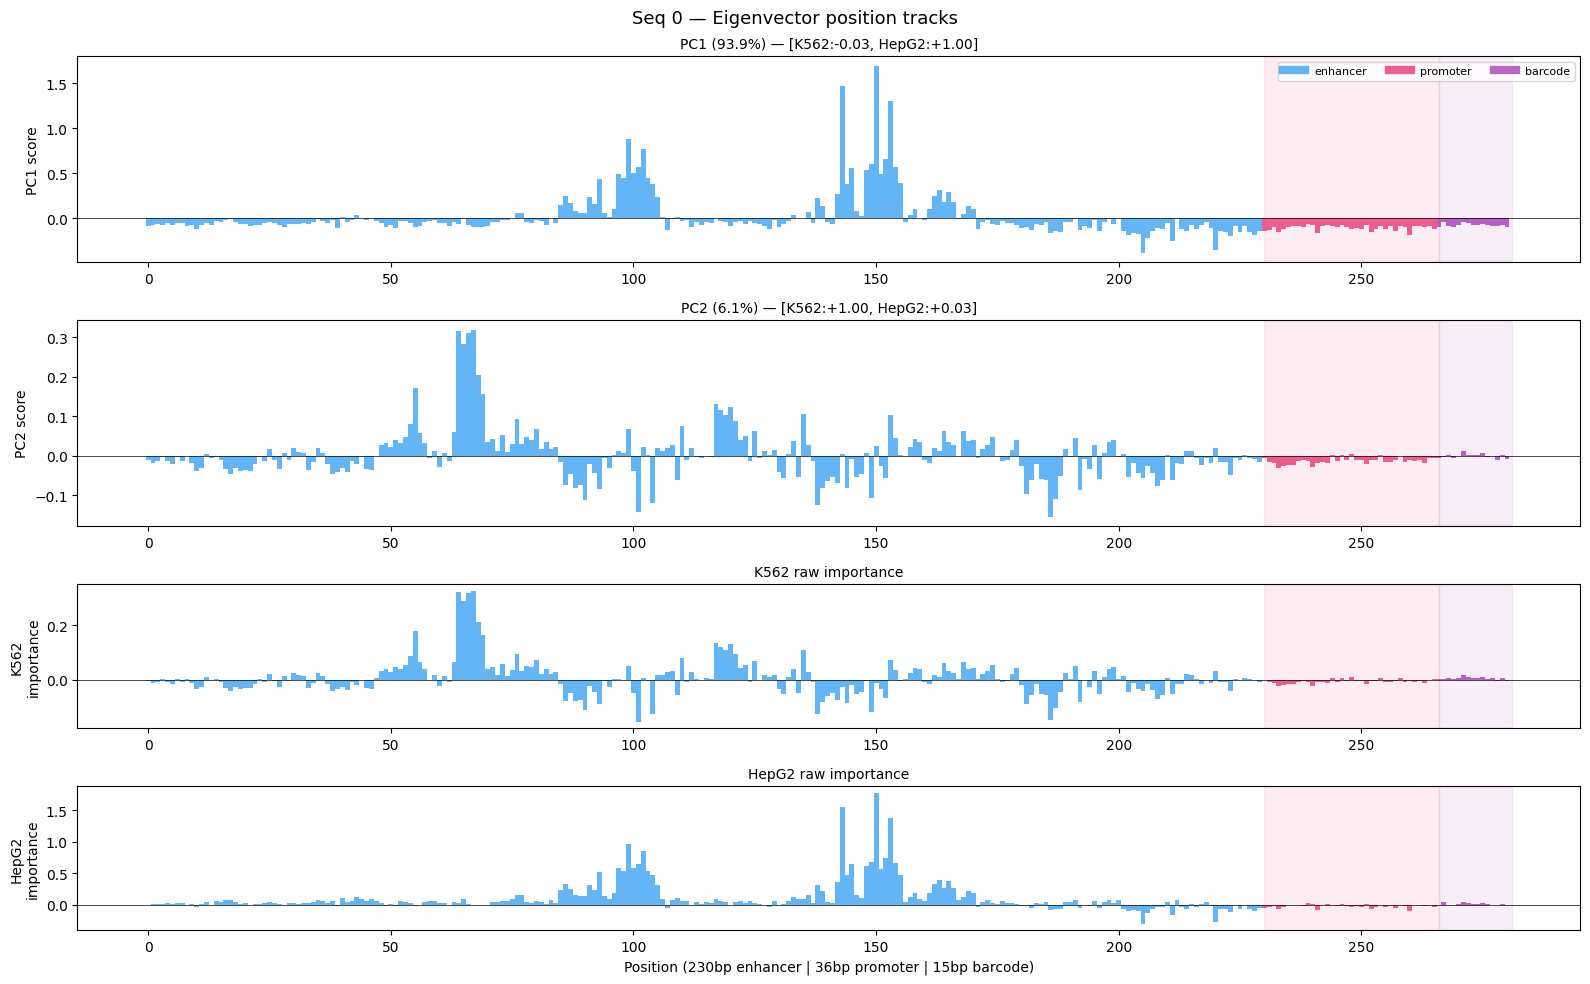

In [28]:
# PC position tracks + raw importance
positions = np.arange(TOTAL_LEN)
bar_colors = np.full(TOTAL_LEN, REGION_COLORS['enhancer'], dtype=object)
bar_colors[promoter_mask] = REGION_COLORS['promoter']
bar_colors[barcode_mask] = REGION_COLORS['barcode']
pc_colors = ['#2196F3', '#FF9800']

fig, axes = plt.subplots(4, 1, figsize=(16, 10),
                         gridspec_kw={'height_ratios': [1, 1, 0.7, 0.7]})
fig.suptitle('Seq 0 — Eigenvector position tracks', fontsize=13)

for pc_i in range(2):
    ax = axes[pc_i]
    ax.bar(positions, scores[:, pc_i], width=1.0, color=bar_colors, alpha=0.7)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvspan(PROMOTER_START, BARCODE_START, alpha=0.08, color=REGION_COLORS['promoter'])
    ax.axvspan(BARCODE_START, TOTAL_LEN, alpha=0.08, color=REGION_COLORS['barcode'])
    loadings = pca.components_[pc_i]
    loading_str = ', '.join(f'{ct}:{w:+.2f}' for ct, w in zip(cell_types, loadings))
    var_pct = pca.explained_variance_ratio_[pc_i] * 100
    ax.set_ylabel(f'PC{pc_i+1} score')
    ax.set_title(f'PC{pc_i+1} ({var_pct:.1f}%) — [{loading_str}]', fontsize=10)

for ci, ct in enumerate(cell_types):
    ax = axes[2 + ci]
    ax.bar(positions, E[:, ci], width=1.0, color=bar_colors, alpha=0.7)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvspan(PROMOTER_START, BARCODE_START, alpha=0.08, color=REGION_COLORS['promoter'])
    ax.axvspan(BARCODE_START, TOTAL_LEN, alpha=0.08, color=REGION_COLORS['barcode'])
    ax.set_ylabel(f'{ct}\nimportance')
    ax.set_title(f'{ct} raw importance', fontsize=10)

axes[-1].set_xlabel('Position (230bp enhancer | 36bp promoter | 15bp barcode)')
region_handles = [Line2D([0], [0], color=REGION_COLORS[r], linewidth=6, alpha=0.7, label=r)
                  for r in ['enhancer', 'promoter', 'barcode']]
axes[0].legend(handles=region_handles, fontsize=8, ncol=3, loc='upper right')
plt.tight_layout()
plt.show()

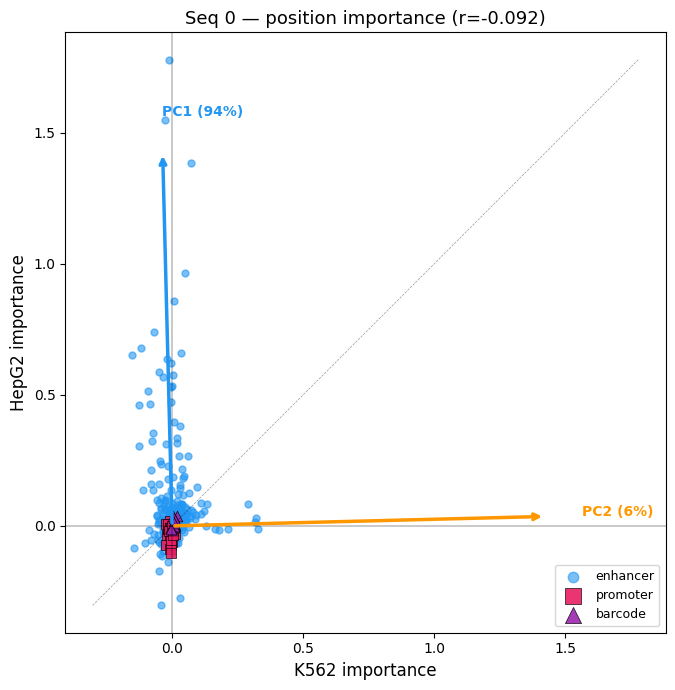

In [29]:
# K562 vs HepG2 scatter with PC axes
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(E[enhancer_mask, 0], E[enhancer_mask, 1],
           c=REGION_COLORS['enhancer'], s=25, marker='o', alpha=0.6, label='enhancer')
ax.scatter(E[promoter_mask, 0], E[promoter_mask, 1],
           c=REGION_COLORS['promoter'], s=60, marker='s', alpha=0.9, label='promoter',
           edgecolors='k', linewidths=0.5)
ax.scatter(E[barcode_mask, 0], E[barcode_mask, 1],
           c=REGION_COLORS['barcode'], s=60, marker='^', alpha=0.9, label='barcode',
           edgecolors='k', linewidths=0.5)

lims = [E.min(), E.max()]
ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.4)

scale = np.abs(E).max() * 0.8
for pc_i in range(2):
    dx, dy = pca.components_[pc_i] * scale
    var_pct = pca.explained_variance_ratio_[pc_i] * 100
    ax.annotate('', xy=(dx, dy), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=pc_colors[pc_i], lw=2.5))
    ax.text(dx * 1.1, dy * 1.1, f'PC{pc_i+1} ({var_pct:.0f}%)',
            color=pc_colors[pc_i], fontsize=10, fontweight='bold')

ax.axhline(0, color='k', linewidth=0.3)
ax.axvline(0, color='k', linewidth=0.3)
r = np.corrcoef(E[:, 0], E[:, 1])[0, 1]
ax.set_xlabel(f'{cell_types[0]} importance', fontsize=12)
ax.set_ylabel(f'{cell_types[1]} importance', fontsize=12)
ax.set_title(f'Seq 0 — position importance (r={r:.3f})', fontsize=13)
ax.legend(fontsize=9, markerscale=1.5)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 5. ISM logos with PC outlier positions annotated

/tmp/slurm_tmp/860540/ipykernel_3558426/1874466542.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


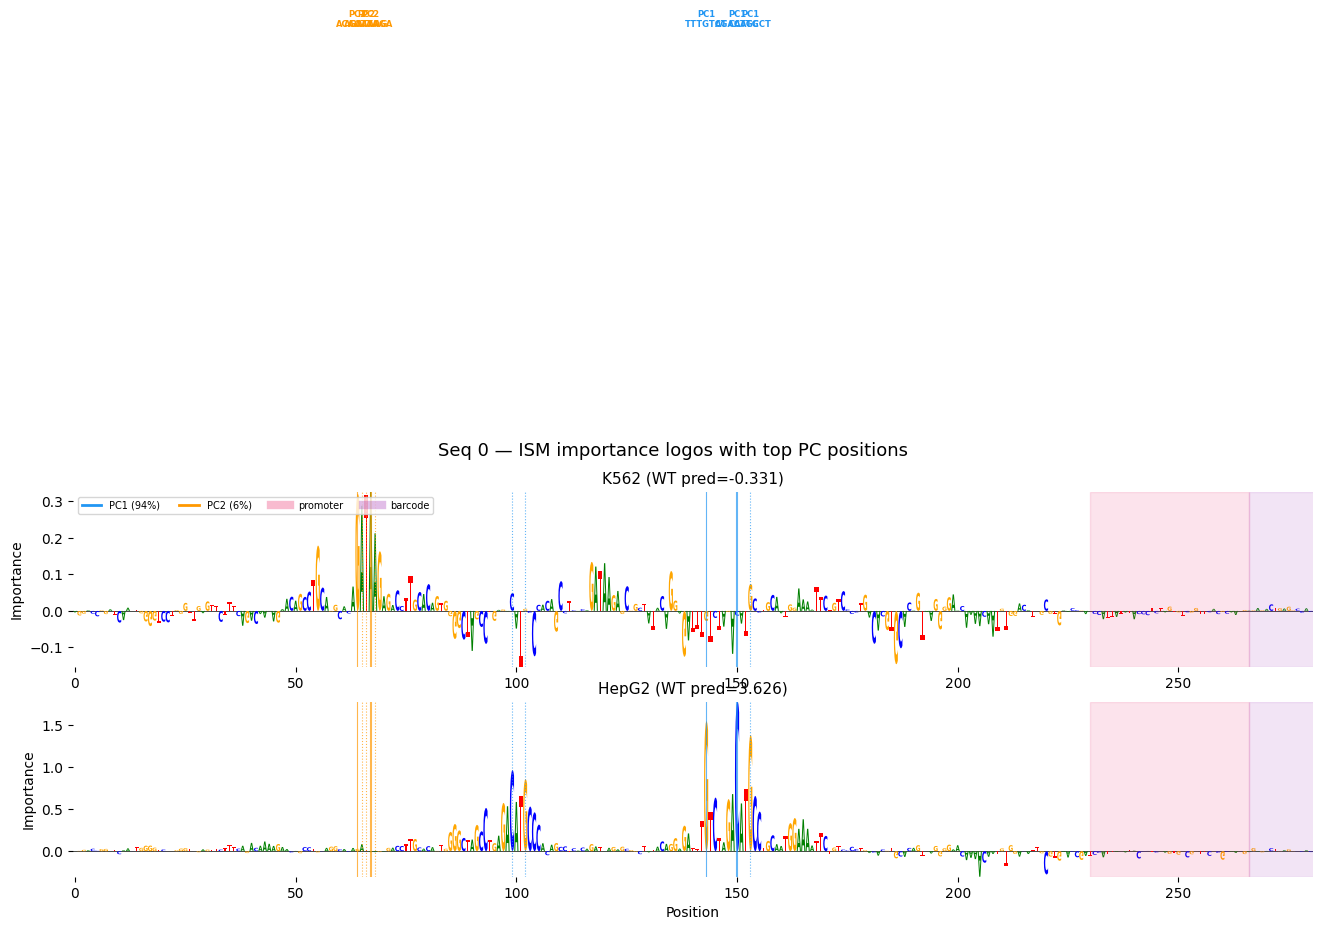

In [30]:
N_TOP = 5
pc_top = {}
for pc_i in range(2):
    pc_top[pc_i] = np.argsort(np.abs(scores[:, pc_i]))[::-1][:N_TOP]

fig, axes = plt.subplots(2, 1, figsize=(16, 5))
fig.suptitle('Seq 0 — ISM importance logos with top PC positions', fontsize=13)

for ci, ct in enumerate(cell_types):
    ax = axes[ci]
    plot_logo(logos[ct], ax=ax, ylim=shared_ylim)
    wt_pred = ism_results[ct][0]
    ax.set_title(f'{ct} (WT pred={wt_pred:.3f})', fontsize=11)
    ax.axvspan(PROMOTER_START, BARCODE_START, alpha=0.12, color=REGION_COLORS['promoter'])
    ax.axvspan(BARCODE_START, TOTAL_LEN, alpha=0.12, color=REGION_COLORS['barcode'])
    
    for pc_i in range(2):
        for rank, p in enumerate(pc_top[pc_i]):
            ax.axvline(p, color=pc_colors[pc_i], linewidth=1.5 if rank == 0 else 0.8,
                       alpha=0.7, linestyle='-' if rank < 2 else ':')
            if ci == 0 and rank < 3:
                start = max(0, p - 3)
                end = min(len(construct), p + 4)
                ctx = construct[start:end]
                ax.text(p, shared_ylim[1] * 0.85, f'PC{pc_i+1}\n{ctx}', fontsize=6,
                        ha='center', color=pc_colors[pc_i], fontweight='bold')
    
    ax.set_ylabel('Importance')
    if ci == 1:
        ax.set_xlabel('Position')

handles = [Line2D([0], [0], color=pc_colors[i], linewidth=2,
           label=f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.0f}%)')
           for i in range(2)]
handles += [Line2D([0], [0], color=REGION_COLORS[r], linewidth=6, alpha=0.3, label=r)
            for r in ['promoter', 'barcode']]
axes[0].legend(handles=handles, fontsize=7, ncol=4, loc='upper left')
plt.tight_layout()
plt.show()

In [31]:
# Top outlier positions with sequence context
seq = construct
print(f'Seq 0 (expr={top_df.iloc[0]["mean_value"]:.3f})')
print('=' * 70)

for pc_i in range(2):
    loadings = pca.components_[pc_i]
    loading_str = ', '.join(f'{ct}:{w:+.3f}' for ct, w in zip(cell_types, loadings))
    var_pct = pca.explained_variance_ratio_[pc_i] * 100
    print(f'\nPC{pc_i+1} ({var_pct:.1f}%) [{loading_str}]')
    
    for rank, p in enumerate(np.argsort(np.abs(scores[:, pc_i]))[::-1][:10]):
        start = max(0, p - 5)
        end = min(len(seq), p + 6)
        ctx = seq[start:end]
        rel = p - start
        ctx_marked = ctx[:rel] + f'[{ctx[rel]}]' + ctx[rel+1:]
        region = 'enh' if p < PROMOTER_START else ('prom' if p < BARCODE_START else 'bc')
        effects = ', '.join(f'{ct}:{E[p, ci]:+.4f}' for ci, ct in enumerate(cell_types))
        print(f'  {rank+1:2d}. pos={p:3d} ({region:4s}) score={scores[p, pc_i]:+.4f}'
              f'  ...{ctx_marked}...  [{effects}]')

Seq 0 (expr=4.410)

PC1 (93.9%) [K562:-0.025, HepG2:+1.000]
   1. pos=150 (enh ) score=+1.6939  ...CTAGA[C]ATGCC...  [K562:-0.0131, HepG2:+1.7781]
   2. pos=143 (enh ) score=+1.4639  ...GATTT[G]TCTAG...  [K562:-0.0277, HepG2:+1.5476]
   3. pos=153 (enh ) score=+1.2975  ...GACAT[G]CCTGC...  [K562:+0.0739, HepG2:+1.3838]
   4. pos= 99 (enh ) score=+0.8798  ...TGAGA[C]ATGCC...  [K562:+0.0489, HepG2:+0.9653]
   5. pos=102 (enh ) score=+0.7731  ...GACAT[G]CCCAC...  [K562:+0.0060, HepG2:+0.8574]
   6. pos=152 (enh ) score=+0.6569  ...AGACA[T]GCCTG...  [K562:-0.0679, HepG2:+0.7393]
   7. pos=149 (enh ) score=+0.5981  ...TCTAG[A]CATGC...  [K562:-0.1176, HepG2:+0.6793]
   8. pos=154 (enh ) score=+0.5726  ...ACATG[C]CTGCA...  [K562:+0.0344, HepG2:+0.6576]
   9. pos=101 (enh ) score=+0.5706  ...AGACA[T]GCCCA...  [K562:-0.1529, HepG2:+0.6509]
  10. pos=145 (enh ) score=+0.5541  ...TTTGT[C]TAGAC...  [K562:-0.0194, HepG2:+0.6377]

PC2 (6.1%) [K562:+1.000, HepG2:+0.025]
   1. pos= 67 (enh ) score=+0.

## 6. Per-sequence eigendecomposition across the joint library (DeepLIFT/SHAP)

Using the joint cross-line library (56k sequences with HepG2, K562, WTC11 measured expression).

For each sequence $i$:
- Compute DeepLIFT/SHAP attributions through K562 and HepG2 models → $A^{(i)}_{\text{ct}} \in \mathbb{R}^{4 \times 281}$
- Per-position importance: $\text{imp}(p) = \sum_b A(b, p)$
- **Z-score normalize** each cell type's importance vector (zero mean, unit variance) so magnitude differences don't bias the decomposition
- Stack into $E_i = (281, 2)$ matrix, eigendecompose → eigenvector 1/2 with weights on each cell type
- Eigenvector 1 weights tell you which cell type dominates; positions scoring high on eigenvector 1 are the motifs driving that cell type
- Attribution logos are L2-normalized per sequence to reveal motif patterns independent of overall magnitude

In [42]:
import pandas as pd

JOINT_CSV = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/Cell_line_MoCon/Cross-line_analysis/pred_first/joint_data/joint_library_combined.csv'
joint_df = pd.read_csv(JOINT_CSV)

# Parse source
def get_source(cat):
    if pd.isna(cat):
        return 'unknown'
    cat = str(cat)
    if 'positive K562' in cat:
        return 'pos_K562'
    if 'positive HepG2' in cat:
        return 'pos_HepG2'
    if 'negative HepG2' in cat:
        return 'neg_HepG2'
    if 'negative' in cat:
        return 'neg'
    if 'promoter' in cat:
        return 'promoter'
    for ct in ['HepG2', 'K562', 'WTC11']:
        if ct in cat:
            return f'enh_{ct}'
    return 'unknown'

joint_df['source'] = joint_df['category'].apply(get_source)

# Keep: enh_HepG2, enh_K562, pos controls, neg controls
# For enhancers: top 10 by HepG2 activity (high activity = interesting motifs)
SOURCES_OF_INTEREST = ['enh_HepG2', 'enh_K562', 'pos_HepG2', 'pos_K562', 'neg_HepG2', 'neg']
N_PER_ENH = 10

samples = []
for src in SOURCES_OF_INTEREST:
    sub = joint_df[joint_df['source'] == src]
    if len(sub) == 0:
        continue
    if src.startswith('enh_'):
        # Top by mean activity across cell lines
        sub = sub.copy()
        sub['mean_activity'] = (sub['HepG2_log2FC'] + sub['K562_log2FC']) / 2
        samples.append(sub.nlargest(N_PER_ENH, 'mean_activity'))
    else:
        # Controls: keep all if small, else sample
        if len(sub) <= 20:
            samples.append(sub)
        else:
            samples.append(sub.sample(N_PER_ENH, random_state=42))

sel_df = pd.concat(samples).reset_index(drop=True)
print(f'Selected {len(sel_df)} sequences:')
print(sel_df['source'].value_counts())
print(f'\nExpression ranges:')
for src in sel_df['source'].unique():
    sub = sel_df[sel_df['source'] == src]
    print(f'  {src:12s}: HepG2=[{sub["HepG2_log2FC"].min():.2f}, {sub["HepG2_log2FC"].max():.2f}], '
          f'K562=[{sub["K562_log2FC"].min():.2f}, {sub["K562_log2FC"].max():.2f}]')

Selected 60 sequences:
source
enh_HepG2    10
enh_K562     10
pos_HepG2    10
pos_K562     10
neg_HepG2    10
neg          10
Name: count, dtype: int64

Expression ranges:
  enh_HepG2   : HepG2=[1.92, 4.08], K562=[1.22, 4.57]
  enh_K562    : HepG2=[2.43, 4.90], K562=[0.90, 4.78]
  pos_HepG2   : HepG2=[1.30, 2.81], K562=[-1.48, -0.59]
  pos_K562    : HepG2=[-0.90, 1.37], K562=[-0.21, 2.67]
  neg_HepG2   : HepG2=[-1.89, 0.55], K562=[-1.34, -0.70]
  neg         : HepG2=[-1.61, -0.48], K562=[-1.78, -0.49]


In [50]:
# Prepare one-hot tensors (230bp seq + 36bp promoter + 15bp barcode = 281bp)
N_SHUFFLES = 20
BATCH_SIZE = 20

X_sel = []
for _, row in sel_df.iterrows():
    seq_c = row['sequence'] + PROMOTER_SEQ + RAND_BARCODE
    assert len(seq_c) == TOTAL_LEN, f"Expected {TOTAL_LEN}bp, got {len(seq_c)}bp"
    ohe = sequence_to_onehot(seq_c).astype(np.float32)
    X_sel.append(torch.from_numpy(ohe).T)
X_sel = torch.stack(X_sel)  # (N, 4, 281)
print(f'X_sel shape: {X_sel.shape}')

# Run DeepLIFT/SHAP for each cell type
attr_by_ct = {}

for ct, model_name in CELL_TYPE_MODELS.items():
    print(f'\n=== {ct} ({model_name}) ===')
    ckpt_path = os.path.join(RESULTS_DIR, model_name, 'checkpoints', 'best_stage2.pt')

    enc = AlphaGenome.from_pretrained(WEIGHTS_PATH, device='cpu')
    remove_all_heads(enc)
    hd = MPRAHead(n_positions=3, nl_size=1024, dropout=0.0,
                  activation='relu', pooling_type='flatten', center_bp=256)
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    enc.load_state_dict(ckpt['model_state_dict'], strict=False)
    hd.load_state_dict(ckpt['head_state_dict'])
    wm = AlphaGenomeMPRA(enc, hd).to(device).eval()

    attr = deep_lift_shap(
        wm, X_sel, target=0,
        n_shuffles=N_SHUFFLES, batch_size=BATCH_SIZE,
        device=str(device),
        additional_nonlinear_ops={AGCustomGELU: _nonlinear},
        warning_threshold=0.01,
        random_state=42,
        verbose=True,
    )
    attr_by_ct[ct] = attr.cpu().numpy()  # (N, 4, 281)
    print(f'  {ct} done. attr shape: {attr_by_ct[ct].shape}')

    del wm, enc, hd, ckpt
    torch.cuda.empty_cache()

# Per-sequence eigendecomposition with NORMALIZED importance
per_seq_results = []

for si in range(len(sel_df)):
    row = sel_df.iloc[si]
    imp = np.column_stack([
        attr_by_ct[ct][si].sum(axis=0) for ct in cell_types
    ])  # (281, 2)

    # Z-score normalize each cell type column so magnitude doesn't bias decomposition
    imp_norm = np.zeros_like(imp)
    for ci in range(imp.shape[1]):
        col = imp[:, ci]
        std = col.std()
        if std > 0:
            imp_norm[:, ci] = (col - col.mean()) / std
        else:
            imp_norm[:, ci] = col - col.mean()

    pca_i = PCA(n_components=2)
    scores_i = pca_i.fit_transform(imp_norm)  # eigendecomposition on normalized data

    # L2-normalize attribution maps for logo visualization
    attr_k562_raw = attr_by_ct['K562'][si]   # (4, 281)
    attr_hepg2_raw = attr_by_ct['HepG2'][si] # (4, 281)
    k562_norm = np.linalg.norm(attr_k562_raw)
    hepg2_norm = np.linalg.norm(attr_hepg2_raw)
    attr_k562_normed = attr_k562_raw / k562_norm if k562_norm > 0 else attr_k562_raw
    attr_hepg2_normed = attr_hepg2_raw / hepg2_norm if hepg2_norm > 0 else attr_hepg2_raw

    per_seq_results.append({
        'idx': si,
        'source': row['source'],
        'name': row['name'],
        'hepg2_expr': row['HepG2_log2FC'],
        'k562_expr': row['K562_log2FC'],
        'imp': imp,              # raw importance
        'imp_norm': imp_norm,    # z-scored importance (used for eigendecomp)
        'attr_k562': attr_k562_normed,    # L2-normalized (4, 281)
        'attr_hepg2': attr_hepg2_normed,  # L2-normalized (4, 281)
        'attr_k562_raw': attr_k562_raw,
        'attr_hepg2_raw': attr_hepg2_raw,
        'pca': pca_i,
        'scores': scores_i,
        'eigvec': pca_i.components_,       # eigenvectors (was 'weights')
        'var_ratio': pca_i.explained_variance_ratio_,
    })

print(f'\nPer-sequence eigendecomposition done for {len(per_seq_results)} sequences.')
print(f'Importance was z-score normalized per cell type before decomposition.')
print(f'Attribution logos are L2-normalized per sequence.')

# Sanity check: show eigenvector weights for first few seqs
for r in per_seq_results[:3]:
    ev = r['eigvec']
    print(f'  {r["source"]:>12s}: EV1=[K562:{ev[0,0]:+.3f}, HepG2:{ev[0,1]:+.3f}] '
          f'EV2=[K562:{ev[1,0]:+.3f}, HepG2:{ev[1,1]:+.3f}] '
          f'var=[{r["var_ratio"][0]*100:.1f}%, {r["var_ratio"][1]*100:.1f}%]')

X_sel shape: torch.Size([60, 4, 281])

=== K562 (K562_twostep_v4_do075) ===


  0%|          | 0/1200 [00:00<?, ?it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.5328, 0.7595, 0.6112, 0.7415, 0.6627, 0.7152, 0.5763, 0.6026, 0.7321,
        0.6707, 0.7872, 0.3351, 0.6425, 0.4710, 0.6471, 0.4316, 0.7037, 0.5269,
        0.7122, 0.4749], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
  2%|▏         | 20/1200 [00:00<00:13, 89.43it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.6651, 0.6529, 0.8044, 0.9051, 0.5340, 0.7317, 0.3522, 0.6746, 0.8327,
        0.7656, 0.6316, 0.5613, 0.7957, 0.7755, 0.5327, 0.6001, 0.6143, 0.5995,
        0.5649, 0.8305], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
  3%|▎         | 

  K562 done. attr shape: (60, 4, 281)

=== HepG2 (HepG2_twostep_v5_do075) ===


  0%|          | 0/1200 [00:00<?, ?it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.1299, 0.5479, 0.0601, 0.3426, 0.1732, 0.2467, 0.3891, 0.0418, 0.4095,
        0.1653, 0.2744, 0.0818, 0.0374, 0.9115, 0.0759, 0.1583, 0.7025, 0.5050,
        0.1847, 0.2264], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
  2%|▏         | 20/1200 [00:00<00:08, 138.57it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.1974, 0.2376, 0.2469, 0.4238, 0.7706, 0.2241, 0.6698, 0.1415, 0.0503,
        0.5009, 0.2028, 0.3731, 0.0979, 0.2080, 0.7509, 0.1717, 0.3767, 0.2924,
        0.7861, 0.0485], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
  3%|▎         |

  HepG2 done. attr shape: (60, 4, 281)

Per-sequence eigendecomposition done for 60 sequences.
Importance was z-score normalized per cell type before decomposition.
Attribution logos are L2-normalized per sequence.
     enh_HepG2: EV1=[K562:+0.707, HepG2:+0.707] EV2=[K562:+0.707, HepG2:-0.707] var=[96.3%, 3.7%]
     enh_HepG2: EV1=[K562:+0.707, HepG2:+0.707] EV2=[K562:-0.707, HepG2:+0.707] var=[97.6%, 2.4%]
     enh_HepG2: EV1=[K562:+0.707, HepG2:+0.707] EV2=[K562:+0.707, HepG2:-0.707] var=[97.7%, 2.3%]


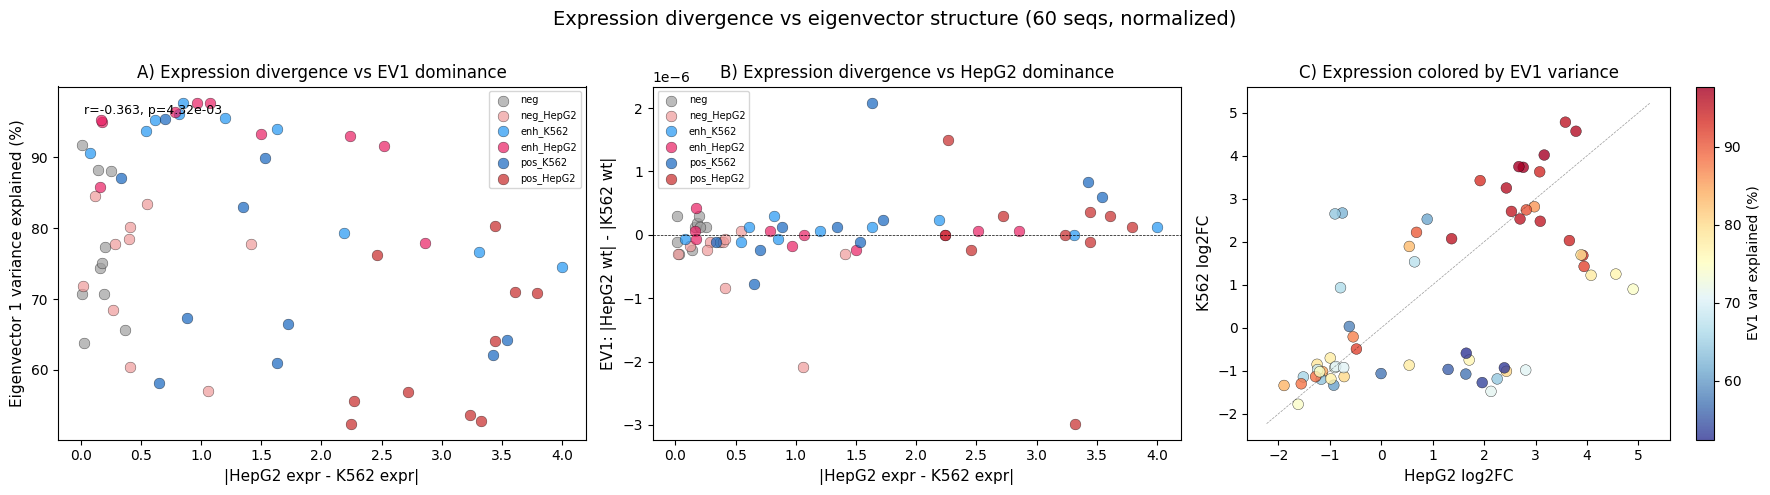

In [51]:
# --- Expression delta vs eigenvector 1 mixedness ---
# Argument: sequences with similar expression across cell lines
# have more "mixed" eigenvectors (neither cell type dominates EV1).
# Sequences with divergent expression have a clear dominant cell type on EV1.

SOURCE_ORDER = ['neg', 'neg_HepG2', 'enh_K562', 'enh_HepG2', 'pos_K562', 'pos_HepG2']
SOURCE_COLORS = {
    'enh_HepG2': '#E91E63', 'enh_K562': '#2196F3',
    'pos_HepG2': '#C62828', 'pos_K562': '#1565C0',
    'neg_HepG2': '#EF9A9A', 'neg': '#9E9E9E',
}
present_sources = [s for s in SOURCE_ORDER if s in set(r['source'] for r in per_seq_results)]

# Organize results by source
by_source = {s: [] for s in present_sources}
for r in per_seq_results:
    if r['source'] in by_source:
        by_source[r['source']].append(r)

# Compute per-sequence metrics
expr_deltas = []
ev1_dominance = []
ev1_var = []
sources = []
for r in per_seq_results:
    delta = abs(r['hepg2_expr'] - r['k562_expr'])
    dom = abs(r['eigvec'][0, 1]) - abs(r['eigvec'][0, 0])  # >0 = HepG2 dominates EV1
    expr_deltas.append(delta)
    ev1_dominance.append(dom)
    ev1_var.append(r['var_ratio'][0] * 100)
    sources.append(r['source'])
expr_deltas = np.array(expr_deltas)
ev1_dominance = np.array(ev1_dominance)
ev1_var = np.array(ev1_var)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: |HepG2 - K562| expression vs EV1 variance explained
ax = axes[0]
for src in present_sources:
    mask = np.array([s == src for s in sources])
    ax.scatter(expr_deltas[mask], ev1_var[mask],
               c=SOURCE_COLORS.get(src, '#757575'), s=60, alpha=0.7,
               label=src, edgecolors='k', linewidths=0.3)
ax.set_xlabel('|HepG2 expr - K562 expr|', fontsize=11)
ax.set_ylabel('Eigenvector 1 variance explained (%)', fontsize=11)
ax.set_title('A) Expression divergence vs EV1 dominance', fontsize=12)
ax.legend(fontsize=7, loc='best')
from scipy.stats import pearsonr
r_val, p_val = pearsonr(expr_deltas, ev1_var)
ax.text(0.05, 0.95, f'r={r_val:.3f}, p={p_val:.2e}', transform=ax.transAxes,
        fontsize=9, va='top')

# Panel B: |HepG2 - K562| expression vs HepG2 dominance on EV1
ax = axes[1]
for src in present_sources:
    mask = np.array([s == src for s in sources])
    ax.scatter(expr_deltas[mask], ev1_dominance[mask],
               c=SOURCE_COLORS.get(src, '#757575'), s=60, alpha=0.7,
               label=src, edgecolors='k', linewidths=0.3)
ax.set_xlabel('|HepG2 expr - K562 expr|', fontsize=11)
ax.set_ylabel('EV1: |HepG2 wt| - |K562 wt|', fontsize=11)
ax.set_title('B) Expression divergence vs HepG2 dominance', fontsize=12)
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.legend(fontsize=7, loc='best')

# Panel C: HepG2 expr vs K562 expr, colored by EV1 variance
ax = axes[2]
sc = ax.scatter([r['hepg2_expr'] for r in per_seq_results],
                [r['k562_expr'] for r in per_seq_results],
                c=ev1_var, cmap='RdYlBu_r', s=60, alpha=0.8,
                edgecolors='k', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='EV1 var explained (%)')
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.4)
ax.set_xlabel('HepG2 log2FC', fontsize=11)
ax.set_ylabel('K562 log2FC', fontsize=11)
ax.set_title('C) Expression colored by EV1 variance', fontsize=12)

plt.suptitle(f'Expression divergence vs eigenvector structure ({len(per_seq_results)} seqs, normalized)',
             fontsize=14)
plt.tight_layout()
plt.show()

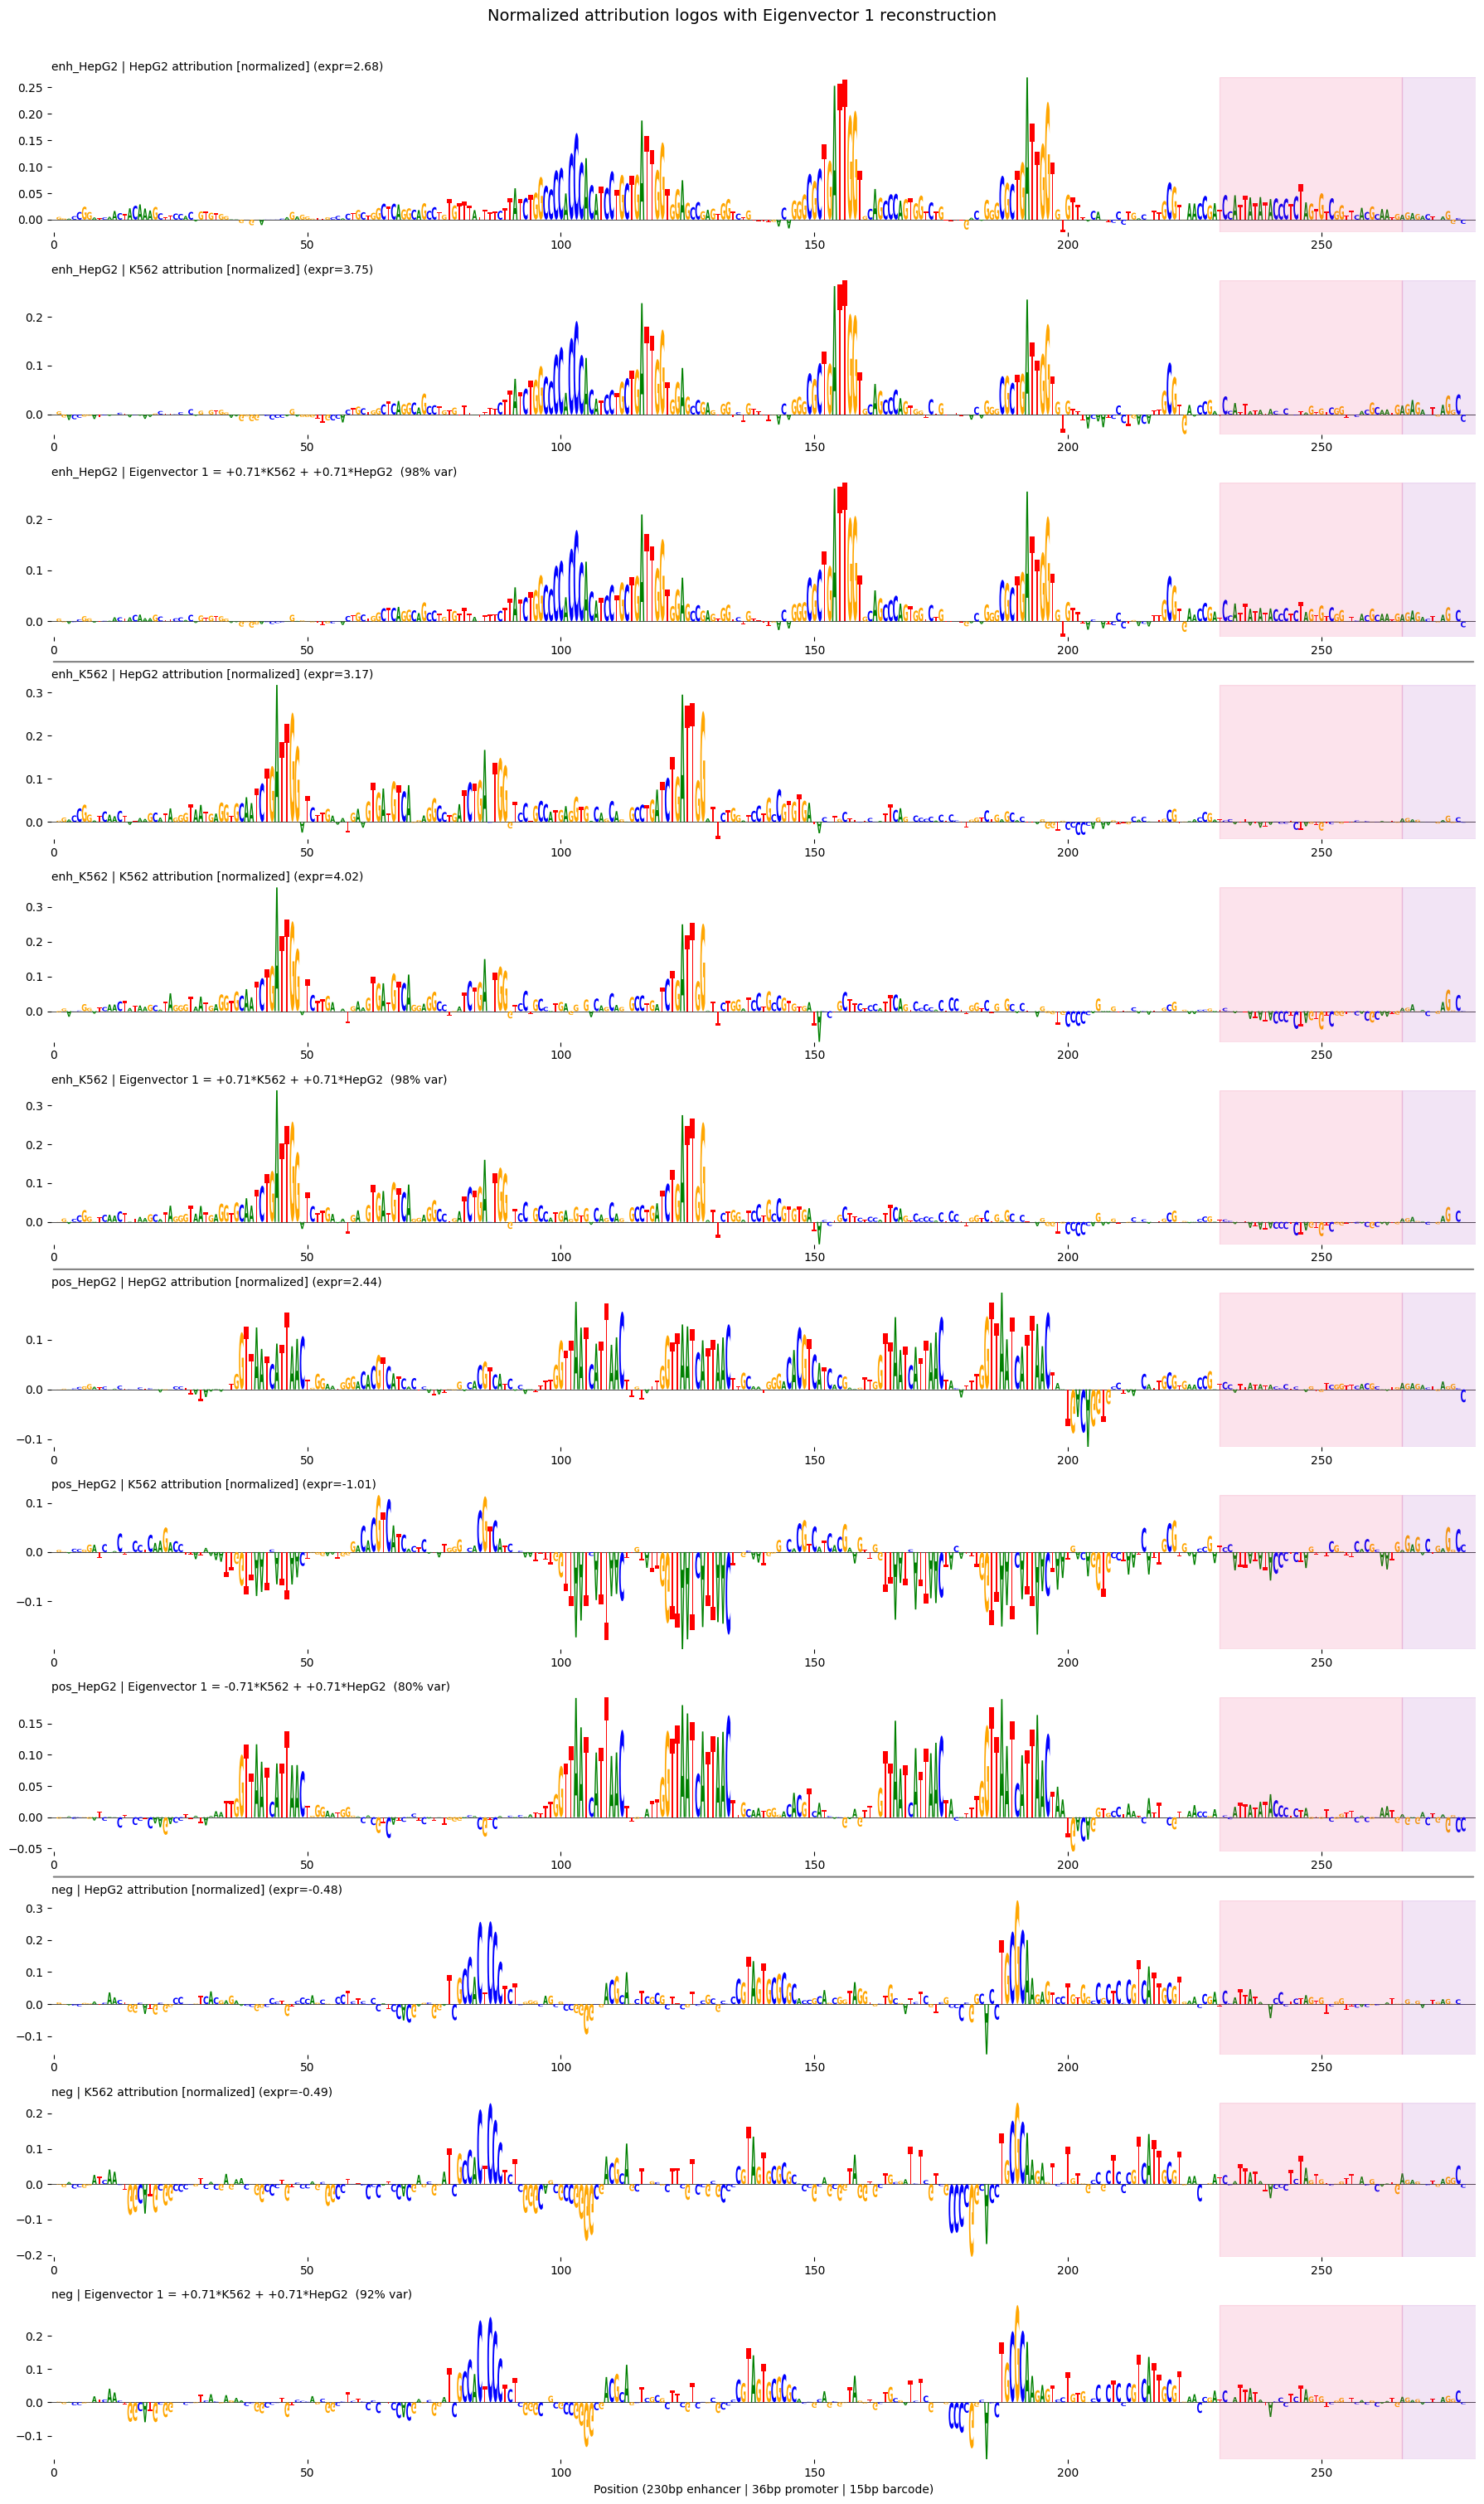


Representative sequences (normalized eigendecomposition):
      Source   HepG2    K562  |delta|  EV1 K562 wt  EV1 HepG2 wt  EV1 var%
   enh_HepG2    2.68    3.75     1.07       +0.707        +0.707      97.7
    enh_K562    3.17    4.02     0.85       +0.707        +0.707      97.6
   pos_HepG2    2.44   -1.01     3.44       -0.707        +0.707      80.3
         neg   -0.48   -0.49     0.01       +0.707        +0.707      91.8


In [52]:
# --- Normalized attribution logos with eigenvector 1 reconstruction (single column) ---
# EV1 logo = w_K562 * attr_K562_norm + w_HepG2 * attr_HepG2_norm
# All logos are L2-normalized so motif patterns are visible regardless of magnitude

show_sources = ['enh_HepG2', 'enh_K562', 'pos_HepG2', 'neg']
show_sources = [s for s in show_sources if s in by_source and len(by_source[s]) > 0]

reps = []
for src in show_sources:
    best = max(by_source[src], key=lambda r: r['var_ratio'][0])
    reps.append(best)

n_rows = len(reps) * 3  # 3 tracks per sequence: HepG2, K562, EV1
fig, axes = plt.subplots(n_rows, 1, figsize=(18, 2.5 * n_rows))

for ri, r in enumerate(reps):
    w_k562, w_hepg2 = r['eigvec'][0, 0], r['eigvec'][0, 1]
    # EV1 logo from normalized attributions
    ev1_logo = w_k562 * r['attr_k562'] + w_hepg2 * r['attr_hepg2']
    # Normalize EV1 logo too
    ev1_norm = np.linalg.norm(ev1_logo)
    if ev1_norm > 0:
        ev1_logo = ev1_logo / ev1_norm

    # Shared y-limits across all 3 tracks (all normalized, should be comparable)
    all_vals = np.concatenate([r['attr_hepg2'].ravel(), r['attr_k562'].ravel(), ev1_logo.ravel()])
    ylim = (-np.abs(all_vals).max() * 1.05, np.abs(all_vals).max() * 1.05)

    tracks = [
        (r['attr_hepg2'], f'{r["source"]} | HepG2 attribution [normalized] (expr={r["hepg2_expr"]:.2f})'),
        (r['attr_k562'],  f'{r["source"]} | K562 attribution [normalized] (expr={r["k562_expr"]:.2f})'),
        (ev1_logo,        f'{r["source"]} | Eigenvector 1 = {w_k562:+.2f}*K562 + {w_hepg2:+.2f}*HepG2  '
                          f'({r["var_ratio"][0]*100:.0f}% var)'),
    ]

    for ti, (logo, title) in enumerate(tracks):
        ax = axes[ri * 3 + ti]
        plot_logo(logo, ax=ax, ylim=ylim)
        ax.axvspan(PROMOTER_START, BARCODE_START, alpha=0.12, color=REGION_COLORS['promoter'])
        ax.axvspan(BARCODE_START, TOTAL_LEN, alpha=0.12, color=REGION_COLORS['barcode'])
        ax.set_title(title, fontsize=10, loc='left')

        # EV1 panel: orange border
        if ti == 2:
            for spine in ax.spines.values():
                spine.set_edgecolor('#FF5722')
                spine.set_linewidth(2)

        # Separator between sequences
        if ti == 0 and ri > 0:
            ax.annotate('', xy=(0, 1.15), xycoords='axes fraction',
                        xytext=(1, 1.15), textcoords='axes fraction',
                        arrowprops=dict(arrowstyle='-', color='grey', lw=1.5))

axes[-1].set_xlabel('Position (230bp enhancer | 36bp promoter | 15bp barcode)')
plt.suptitle('Normalized attribution logos with Eigenvector 1 reconstruction',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

# Summary table
print('\nRepresentative sequences (normalized eigendecomposition):')
print(f'{"Source":>12s}  {"HepG2":>6s}  {"K562":>6s}  {"|delta|":>7s}  '
      f'{"EV1 K562 wt":>11s}  {"EV1 HepG2 wt":>12s}  {"EV1 var%":>8s}')
for r in reps:
    delta = abs(r['hepg2_expr'] - r['k562_expr'])
    print(f'{r["source"]:>12s}  {r["hepg2_expr"]:6.2f}  {r["k562_expr"]:6.2f}  {delta:7.2f}  '
          f'{r["eigvec"][0,0]:+11.3f}  {r["eigvec"][0,1]:+12.3f}  '
          f'{r["var_ratio"][0]*100:8.1f}')